# Final Exam 25 - Part 2: ViT & Semi-Supervised Learning

## Q1. ViT

In the assignment, you have fine-tuned a ViT on sports-classification dataset

Load your fine tuned model and run the image at **vit_data/test.webp** through the model. Provide your code and the output here. Does your model correctly classify the image?

I have provided you with the fine-tuned weight in folder **vit_weight** and the class lable at **vit_data/sport.csv**

In [9]:
import os
import time
import torch
import torch.nn as nn
from torchvision.models import vit_b_16 as ViT, ViT_B_16_Weights

from torchvision import transforms
from torch.utils.data import DataLoader
import pandas as pd

from tqdm import tqdm

# Set the GPU Device
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
print(device)

cuda:1


In [10]:
model = ViT(weights=ViT_B_16_Weights.DEFAULT)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"{total_params/1000000}M")

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [11]:
# Changed to out_features = 100
model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=100, bias=True))

# Move the model to Device
model.to(device)
print("Classifier Head: ", model.heads)

Classifier Head:  Sequential(
  (0): Linear(in_features=768, out_features=100, bias=True)
)


In [12]:
print("### Start Loading Model ###")
model.load_state_dict(torch.load('vit_weight/Ep.7.pth',  map_location=device))
print("### Finished Loading Model ###")

### Start Loading Model ###
### Finished Loading Model ###


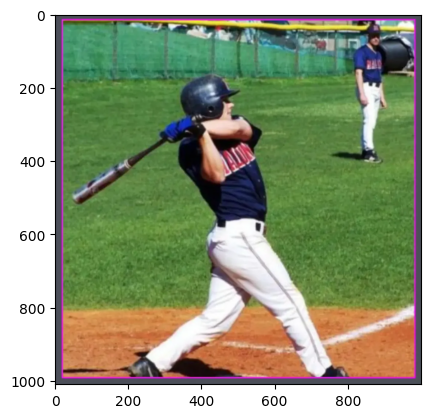

In [13]:
from PIL import Image
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

img = Image.open("vit_data/test.webp").convert('RGB')
plt.imshow(img)

In [16]:
class_df = pd.read_csv('vit_data/sports.csv', usecols=['class id', 'filepaths', 'labels', 'data set'])
class_dict = { row[0]:row[1] for i, row in class_df.iterrows()}
print("class dict: ", class_dict)

/tmp/ipykernel_1510225/1705754971.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  class_dict = { row[0]:row[1] for i, row in class_df.iterrows()}


class dict:  {0: 'valid/air hockey/5.jpg', 1: 'valid/ampute football/5.jpg', 2: 'valid/archery/5.jpg', 3: 'valid/arm wrestling/5.jpg', 4: 'valid/axe throwing/5.jpg', 5: 'valid/balance beam/5.jpg', 6: 'valid/barell racing/5.jpg', 7: 'valid/baseball/5.jpg', 8: 'valid/basketball/5.jpg', 9: 'valid/baton twirling/5.jpg', 10: 'valid/bike polo/5.jpg', 11: 'valid/billiards/5.jpg', 12: 'valid/bmx/5.jpg', 13: 'valid/bobsled/5.jpg', 14: 'valid/bowling/5.jpg', 15: 'valid/boxing/5.jpg', 16: 'valid/bull riding/5.jpg', 17: 'valid/bungee jumping/5.jpg', 18: 'valid/canoe slamon/5.jpg', 19: 'valid/cheerleading/5.jpg', 20: 'valid/chuckwagon racing/5.jpg', 21: 'valid/cricket/5.jpg', 22: 'valid/croquet/5.jpg', 23: 'valid/curling/5.jpg', 24: 'valid/disc golf/5.jpg', 25: 'valid/fencing/5.jpg', 26: 'valid/field hockey/5.jpg', 27: 'valid/figure skating men/5.jpg', 28: 'valid/figure skating pairs/5.jpg', 29: 'valid/figure skating women/5.jpg', 30: 'valid/fly fishing/5.jpg', 31: 'valid/football/5.jpg', 32: 'vali

In [19]:
# sample execution (requires torchvision)
from PIL import Image
from torchvision import transforms
input_image = Image.open("vit_data/test.webp").convert('RGB')
preprocess = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
input_tensor = preprocess(input_image)
input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

# move the input and model to GPU for speed if available
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    model.to('cuda')

with torch.no_grad():
  output = model(input_batch)

In [20]:
_, prediction = torch.max(output, dim=1)
print(f'Predict Result : {[class_dict[c] for c in prediction.tolist()]}')

Predict Result : ['valid/baseball/5.jpg']


## Q2. DINO

The DINO (Distillation with No Labels) model is a cutting-edge self-supervised learning method applied to vision transformers (ViTs). 

<img src="img/DINO.png" title="ResNet18" style="width: 400px;" />

In the DINO model, the student-teacher network is a core mechanism that enables self-supervised learning without labeled data. This framework involves two networks: the student network and the teacher network. Both networks are vision transformers, which are designed to process images by treating them as sequences of patches, similar to how transformers handle text sequences.

The student network is tasked with learning to generate meaningful representations from input images. The teacher network, on the other hand, provides target representations that the student network aims to match. The teacher network is not a static entity; it evolves over time by gradually incorporating the parameters of the student network. This is done using a technique called exponential moving average, where the teacher’s parameters are updated to be a weighted average of its current parameters and the student’s parameters.

The objective is to minimize the discrepancy between the student’s representations and the teacher’s representations for the same augmented image views. This is typically achieved using a loss function that encourages alignment between the student and teacher outputs while ensuring that the representations of different images remain distinct.

By continuously updating the teacher network based on the student network’s learning progress and training the student network to match the teacher’s output, DINO effectively leverages the strengths of both networks. The teacher network provides stable and consistent targets for the student, while the student network drives the learning process. This collaborative setup allows the model to learn robust and invariant features from the data without the need for manual labels, thereby achieving effective self-supervised learning.


As for today's exam i would like you to

    - Construct distillation_loss
    
#### Construct distillation_loss

Below, I have prepared a `DINO` class for you, which implements the key components of the DINO (Distillation with No Labels) framework — including the student and teacher networks, teacher updating, and the structure for the loss calculation.

Now, **your task** is to complete the `distillation_loss` static method inside the class.
This function is critical because it measures how well the student network matches the teacher network, with special handling for centering, sharpening, and avoiding backpropagation through the teacher. 

Hint: this `distillation_loss` is equalvalent to `def H(t,s)` in Algorithm 1 DINO PyTorch pseudocode w/o multi-crop (instead of that, inthis pseudo code it is simply the `augment()` function). 

<img src="img/DINO_Alg.png" title="ResNet18" style="width: 400px;" />


In [4]:
import torch
from typing import Callable

class DINO(torch.nn.Module):
    def __init__(self, student_arch: Callable, teacher_arch: Callable, device: torch.device):
        """
        Args:
            student_arch (torch.nn.Module): ViT Network for student_arch
            teacher_arch (torch.nn.Module): ViT Network for teacher_arch
            device: torch.device ('cuda' or 'cpu')
        """
        super(DINO, self).__init__()
    
        self.student = student_arch().to(device)
        self.teacher = teacher_arch().to(device)
        self.teacher.load_state_dict(self.student.state_dict())

        # Initialize center as buffer to avoid backpropagation
        self.register_buffer('center', torch.zeros(1, student_arch().output_dim))

        # Ensure the teacher parameters do not get updated during backprop
        for param in self.teacher.parameters():
            param.requires_grad = False

    @staticmethod
    def distillation_loss(student_output, teacher_output, center, tau_s, tau_t):
        """
        Calculates distillation loss with centering and sharpening (function H in pseudocode).
        """
        # Detach teacher output to stop gradients.
        teacher_output = teacher_output.detach()

        # Center and sharpen teacher's outputs
        teacher_probs = F.softmax((teacher_output - center) / tau_t, dim=1)

        # Sharpen student's outputs
        student_probs = F.log_softmax(student_output / tau_s, dim=1)

        # Calculate cross-entropy loss between student's and teacher's probabilities.
        loss = - (teacher_probs * student_probs).sum(dim=1).mean()
        return loss

    def teacher_update(self, beta: float):
        for teacher_params, student_params in zip(self.teacher.parameters(), self.student.parameters()):
            teacher_params.data.mul_(beta).add_(student_params.data, alpha=(1 - beta))

In [7]:
# Test your function
import torch
import torch.nn.functional as F

# Create random fake outputs for student and teacher
batch_size = 8
num_classes = 10

student_output = torch.randn(batch_size, num_classes)
teacher_output = torch.randn(batch_size, num_classes)
center = torch.randn(1, num_classes)

# Temperatures
tau_s = 0.1
tau_t = 0.04

# Call the distillation_loss
loss = DINO.distillation_loss(student_output, teacher_output, center, tau_s, tau_t)

print(f"Distillation loss: {loss.item():.6f}")

Distillation loss: 12.061220
